# Analysing Company ESG performance - Data preparation 

## Objectives



## Inputs

* An exported CSV file (public_company_esg_ratings_cleaned.csv) 

The dataset for this project was downloaded from Kaggle: https://www.kaggle.com/datasets/alistairking/public-company-esg-ratings-dataset



## Outputs



## Additional Comments






# Change working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir 

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis\\jupyter_notebooks'

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\chheb\\OneDrive\\Documents\\Programming\\Unit 1 Assessment - ESG Performance\\esg_corporate_analysis'

# Import project dependencies and data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
df = pd.read_csv("data/public_company_esg_ratings_cleaned.csv")

In [6]:
df.head()

,ticker,name,currency,exchange,industry,environment_grade,environment_level,social_grade,social_level,governance_grade,governance_level,environment_score,social_score,governance_score,total_score,total_grade,total_level,environment_score_norm,social_score_norm,governance_score_norm
0,dis,Walt Disney Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,A,High,BB,Medium,BB,Medium,510,316,321,1147,BBB,High,0.60,0.31,0.62
1,gm,General Motors Co,USD,"NEW YORK STOCK EXCHANGE, INC.",Automobiles,A,High,BB,Medium,B,Medium,510,303,255,1068,BBB,High,0.60,0.28,0.45
2,gww,WW Grainger Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Trading Companies and Distributors,B,Medium,BB,Medium,B,Medium,255,385,240,880,BB,Medium,0.11,0.44,0.41
3,mhk,Mohawk Industries Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Consumer products,A,High,B,Medium,BB,Medium,570,298,303,1171,BBB,High,0.71,0.27,0.57
4,lyv,Live Nation Entertainment Inc,USD,"NEW YORK STOCK EXCHANGE, INC.",Media,BBB,High,BB,Medium,B,Medium,492,310,250,1052,BBB,High,0.56,0.30,0.44


# Exploring the data through visualisations 

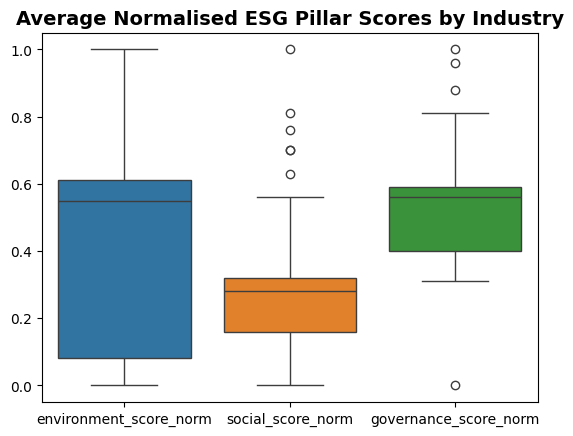

In [7]:
sns.boxplot(data=df[["environment_score_norm", "social_score_norm", "governance_score_norm"]])
plt.title("Average Normalised ESG Pillar Scores by Industry", fontsize=14, fontweight="bold")
plt.show()

## Pillar comparison: raw scores vs. normalised scores

Creating a new version of the boxplot we used to show the outliers in the original dataset again with the normalised version shows a clear differenece in the balance between the ESG pillars. 

The initial inspection of raw pillar score means (environment_score ≈405, social_score ≈292, governance_score ≈279) suggested a fairly smooth, proportional decline across the three pillars. Environment being the highest, followed by Social in the middle and Governance being the lowest. No one pillar stood out as dramatically different from the others.

Using the normalised scores changes the picture. The Environment (median ≈0.55) and Governance (median ≈0.56) pillars remain in very similar positions, but the Social (median ≈0.27) now sits meaningfully lower — roughly half the level of the other two pillars. This shows why normalisation was a necessary step before drawing conclusions: Governance was never genuinely behind Environment — it simply operated on a smaller numeric range. The real gap is between Social and the other two pillars.

### Reflection: is Social's lower performance surprising?

This result initially seemed counter-intuitive to me. I had assumed from my own experience interviewing stakeholders from businesses opertaing in the USA that social initiatives such as DEI and inclusive hiring policies are often faster and easier for companies to implement than environmental or governance reforms (which can require substantial structural or long-term investment). 

BUT...

The Social pillar in this rating likely covers far more than DEI alone. It potentially includes labour practices, supply chain human rights, product safety, and data privacy. It is also worth restating that this dataset does not disclose its rating methodology. It's possible the Social criteria are simply scored on a stricter basis than Environment or Governance, independent of actual company performance.
It could also be the case that social policies like wellbeing initiatives may be easier to announce than to substantiate under third-party scrutiny.

Without visibility into the rating agency's methodology, it isn't possible to say which explanation (or combination) is correct from this dataset alone.

## Comparing different industries 

To move from an overall pillar comparison to a more focused industry-level view, I calculated the average normalised pillar scores per industry using groupby("industry"). Before this comparison could be considered reliable, industry sample sizes were checked using .value_counts(). This showed that there is a  a highly uneven distribution — ranging from 63 companies in Technology down to just 2 in Tobacco. The dataset had a natural three-tier structure with a handful of large industries, a mid-sized cluster and a long tail of small ones.

Since averaging scores across a group with only 2-3 companies would not produce a statistically meaningful comparison, I applied a minimum threshold of 10 companies per industry. This reduced the dataset from 44 to 23 industries. This cutoff was chosen deliberately at a natural gap in the company-count distribution rather than an arbitrary round number. The "Unknown" industry category (companies with missing industry data) was also explicitly excluded at this stage. This was not for statistical reasons, since it exceeded the count threshold. It was because it does not represent a comparable industry.

The resulting 23-industry averages were visualised using a horizontal grouped bar chart, with one bar per pillar per industry. A horizontal orientation was used to accommodate the number of industries and their label lengths more readably than a vertical layout. An overlapping-bar variant was also tested for comparison, but the grouped (side-by-side) version proved clearer. Since Environment and Governance scores are frequently close in value across industries, making an overlapping layout harder to make sense of visually.



In [8]:
df['industry'].unique()

array(['Media', 'Automobiles', 'Trading Companies and Distributors',
       'Consumer products', 'Hotels Restaurants and Leisure',
       'Diversified Consumer Services', 'Airlines', 'Insurance',
       'Communications', 'Building', 'Technology', 'Electrical Equipment',
       'Logistics and Transportation', 'Unknown', 'Biotechnology',
       'Health Care', 'Life Sciences Tools and Services', 'Banking',
       'Semiconductors', 'Pharmaceuticals', 'Financial Services',
       'Commercial Services and Supplies', 'Chemicals', 'Real Estate',
       'Utilities', 'Machinery', 'Food Products', 'Retail', 'Energy',
       'Road and Rail', 'Distributors', 'Beverages', 'Telecommunication',
       'Professional Services', 'Auto Components', 'Packaging',
       'Aerospace and Defense', 'Tobacco', 'Metals and Mining',
       'Construction', 'Textiles Apparel and Luxury Goods',
       'Industrial Conglomerates', 'Leisure Products', 'Marine'],
      dtype=object)

In [9]:
industry_counts = df['industry'].value_counts()
print(industry_counts)

industry
Technology                            63
Biotechnology                         56
Health Care                           51
Real Estate                           36
Financial Services                    33
Utilities                             30
Banking                               29
Electrical Equipment                  27
Insurance                             27
Retail                                26
Semiconductors                        24
Hotels Restaurants and Leisure        24
Media                                 23
Machinery                             21
Pharmaceuticals                       21
Energy                                21
Consumer products                     20
Chemicals                             19
Life Sciences Tools and Services      16
Food Products                         14
Unknown                               13
Aerospace and Defense                 11
Building                              10
Metals and Mining                     10
Textile

In [10]:
df.groupby("industry")[["environment_score_norm", "social_score_norm", "governance_score_norm"]].mean().round(2)

,environment_score_norm,social_score_norm,governance_score_norm
industry,,,
Aerospace and Defense,0.51,0.27,0.54
Airlines,0.24,0.21,0.43
Auto Components,0.27,0.17,0.43
Automobiles,0.37,0.14,0.40
Banking,0.27,0.26,0.47
Beverages,0.53,0.28,0.53
Biotechnology,0.21,0.22,0.54
Building,0.53,0.29,0.54
Chemicals,0.51,0.29,0.54


In [11]:
valid_industries = industry_counts[industry_counts >= 10].index

df_filtered = df[(df["industry"].isin(valid_industries)) & (df["industry"] != "Unknown")]

df_filtered["industry"].nunique()

23

In [12]:
industry_pillar_avg = df_filtered.groupby("industry")[["environment_score_norm", "social_score_norm", "governance_score_norm"]].mean()
industry_pillar_avg.round(2)

,environment_score_norm,social_score_norm,governance_score_norm
industry,,,
Aerospace and Defense,0.51,0.27,0.54
Banking,0.27,0.26,0.47
Biotechnology,0.21,0.22,0.54
Building,0.53,0.29,0.54
Chemicals,0.51,0.29,0.54
Consumer products,0.36,0.25,0.50
Electrical Equipment,0.35,0.22,0.51
Energy,0.61,0.29,0.55
Financial Services,0.32,0.23,0.48


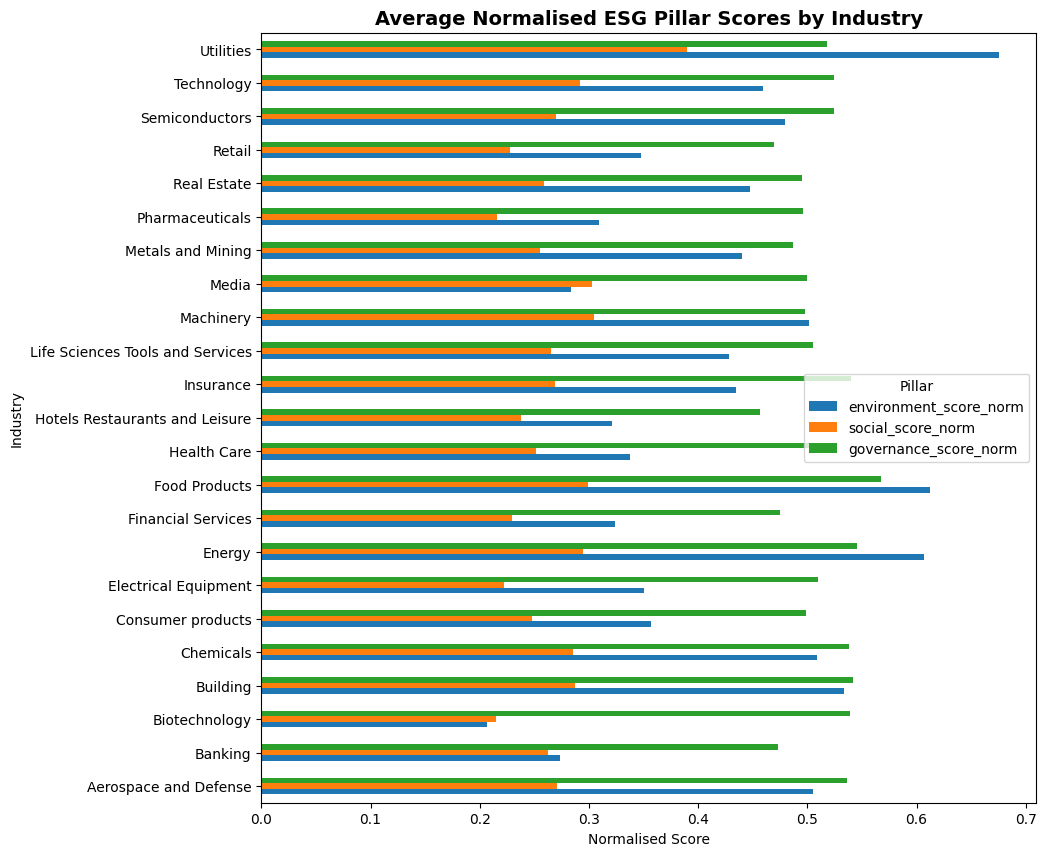

In [13]:
industry_pillar_avg.plot(kind="barh", figsize=(10, 10))
plt.title("Average Normalised ESG Pillar Scores by Industry", fontsize=14, fontweight="bold")
plt.xlabel("Normalised Score")
plt.ylabel("Industry")
plt.legend(title="Pillar")
plt.show()

In [14]:
industry_pillar_avg.idxmax(axis=1)

industry
Aerospace and Defense                governance_score_norm
Banking                              governance_score_norm
Biotechnology                        governance_score_norm
Building                             governance_score_norm
Chemicals                            governance_score_norm
Consumer products                    governance_score_norm
Electrical Equipment                 governance_score_norm
Energy                              environment_score_norm
Financial Services                   governance_score_norm
Food Products                       environment_score_norm
Health Care                          governance_score_norm
Hotels Restaurants and Leisure       governance_score_norm
Insurance                            governance_score_norm
Life Sciences Tools and Services     governance_score_norm
Machinery                           environment_score_norm
Media                                governance_score_norm
Metals and Mining                    governance

In [15]:
industry_pillar_avg.idxmin(axis=1)

industry
Aerospace and Defense                    social_score_norm
Banking                                  social_score_norm
Biotechnology                       environment_score_norm
Building                                 social_score_norm
Chemicals                                social_score_norm
Consumer products                        social_score_norm
Electrical Equipment                     social_score_norm
Energy                                   social_score_norm
Financial Services                       social_score_norm
Food Products                            social_score_norm
Health Care                              social_score_norm
Hotels Restaurants and Leisure           social_score_norm
Insurance                                social_score_norm
Life Sciences Tools and Services         social_score_norm
Machinery                                social_score_norm
Media                               environment_score_norm
Metals and Mining                        social

In [16]:
lowest_pillar_counts = industry_pillar_avg.idxmin(axis=1).value_counts()
highest_pillar_counts = industry_pillar_avg.idxmax(axis=1).value_counts()

print(lowest_pillar_counts)
print(highest_pillar_counts)

social_score_norm         21
environment_score_norm     2
Name: count, dtype: int64
governance_score_norm     19
environment_score_norm     4
Name: count, dtype: int64


### Key finding: consistent Social pillar underperformance across industries

My initial visual inspection of the chart suggested that the Social pillar scored lowest in nearly every industry, with Governance most frequently the highest-scoring pillar. I decided to verify this using .idxmin(axis=1) and .idxmax(axis=1) to identify the lowest- and highest-scoring pillar for each individual industry row. It's a good thing I did, because my visual inspection had totally missed the Machinery industry also having a higher environmental score then governance.

I confirmed that Social is the lowest-scoring pillar for 21 of 23 industries — only Biotechnology and Media breaking the pattern. Governance was the highest-scoring pillar in 14 of 23 industries, with Environment being the highest scoring pillar in four specific industries: Food Products, Utilities, Energy, and Machinery. I believe this is likely explained by these sectors' direct environmental impact and regulatory exposure compared to other sectors like Banking or Insurance.

This represents strong evidence of the pillar imbalance this project set out to investigate. Rather than being random or industry-specific, the performance imbalance across ESG pillars follows a consistent structural pattern of Social lagging almost universally.

## Pillar imbalance analysis

### Calculating a per-company imbalance metric

In order to directly address the project's core question of whether ESG pillar performance imbalance can be mapped across different industries, I created a single imbalance metric ("pillar_imbalance") for each company.

I found this conceptually quite difficult as well as fiddly when it came to the code. I calculated pillar_imbalance using the normalised pillar scores. This was consistent with earlier findings that raw scores are not directly comparable due to differing underlying scales across pillars. A company with balanced ESG performance produces a low imbalance value close to 0; a company scoring well on one pillar while scoring lower on another produces a value closer to 1.

I verified this formula by using CMS Energy. I had already identified this company during earlier outlier analysis as holding both the highest Social score and lowest Governance score. As expected, this produced a pillar_imbalance value of 1.0 (the theoretical maximum), confirming the calculation behaves correctly. I then applied it across the full dataset.

In [17]:
pillar_columns = ["environment_score_norm", "social_score_norm", "governance_score_norm"]

df["pillar_imbalance"] = df[pillar_columns].max(axis=1) - df[pillar_columns].min(axis=1)

df["pillar_imbalance"] = df["pillar_imbalance"].round(2)

df[["name", "environment_score_norm", "social_score_norm", "governance_score_norm", "pillar_imbalance"]].head()

,name,environment_score_norm,social_score_norm,governance_score_norm,pillar_imbalance
0,Walt Disney Co,0.60,0.31,0.62,0.31
1,General Motors Co,0.60,0.28,0.45,0.32
2,WW Grainger Inc,0.11,0.44,0.41,0.33
3,Mohawk Industries Inc,0.71,0.27,0.57,0.44
4,Live Nation Entertainment Inc,0.56,0.30,0.44,0.26


In [18]:
df_company_check = df[df["name"] == "CMS Energy Corp"]

df_company_check[["name", "environment_score_norm", "social_score_norm", "governance_score_norm", "pillar_imbalance"]]

,name,environment_score_norm,social_score_norm,governance_score_norm,pillar_imbalance
457,CMS Energy Corp,0.48,1.0,0.0,1.0


### Ranking industries by average imbalance

The average pillar imbalance was then calculated for each industry (using the same filtered, thresholded dataset established earlier which excluded industries with fewer than 10 companies and the "Unknown" category). This was added alongside each industry's average normalised pillar scores for context.

Sorting by imbalance surfaced the most and least balanced industries directly, rather than needing me to manually compare across an alphabetically-ordered table.

NOTE:

While building the industry-level imbalance table, df_filtered.groupby(...) initially failed to run as expected because the pillar_imbalance column did not yet exist in df_filtered. I used AI to troubleshoot this with me. I was able to identify the issue and was able to diagnose it methodically rather than through trial and error. First, I checked "pillar_imbalance" in df_filtered.columns directly. This  confirmed the column was missing. The reason for this was that df_filtered had been created earlier in the notebook, before pillar_imbalance was added to the parent df. This meant that df_filtered was working from data that was not up-to-date. The fix was to re-run the original filtering against the current, updated df, which correctly carried the new column through. 

In [19]:
df_filtered = df[(df["industry"].isin(valid_industries)) & (df["industry"] != "Unknown")]

"pillar_imbalance" in df_filtered.columns

True

In [20]:
industry_imbalance = df_filtered.groupby("industry")[["pillar_imbalance", "environment_score_norm", "social_score_norm", "governance_score_norm"]].mean().round(2)
industry_imbalance = industry_imbalance.sort_values("pillar_imbalance", ascending=False)
industry_imbalance

,pillar_imbalance,environment_score_norm,social_score_norm,governance_score_norm
industry,,,,
Biotechnology,0.41,0.21,0.22,0.54
Energy,0.39,0.61,0.29,0.55
Electrical Equipment,0.37,0.35,0.22,0.51
Utilities,0.36,0.68,0.39,0.52
Media,0.36,0.28,0.30,0.50
Building,0.36,0.53,0.29,0.54
Life Sciences Tools and Services,0.36,0.43,0.27,0.50
Pharmaceuticals,0.35,0.31,0.22,0.50
Insurance,0.35,0.43,0.27,0.54


### Finding: two distinct "shapes" of imbalance

Using our earlier bar plot, the four most imbalanced industries — Biotechnology, Energy, Electrical Equipment, and Utilities — initially appeared to share a single characteristic (high imbalance). But closer inspection of their individual pillar averages showed there are actually two different underlying patterns:

1. Environmentally-led imbalance (Utilities, Energy): one pillar, Environment, scores substantially higher than the other two, which sit closer to typical levels. 
2. Governance-propped imbalance (Biotechnology, Electrical Equipment): the opposite pattern — Governance remains relatively strong while both Environment and Social underperform together.

This distinction is important because it shows that a single imbalance score alone cannot differentiate between these two situations. They both show as "highly imbalanced," despite representing different company/industry behaviour. This is a limitation of using a single summary metric on its own. It is also why I kept the underlying pillar averages alongside the imbalance score rather than relying on the imbalance number alone.

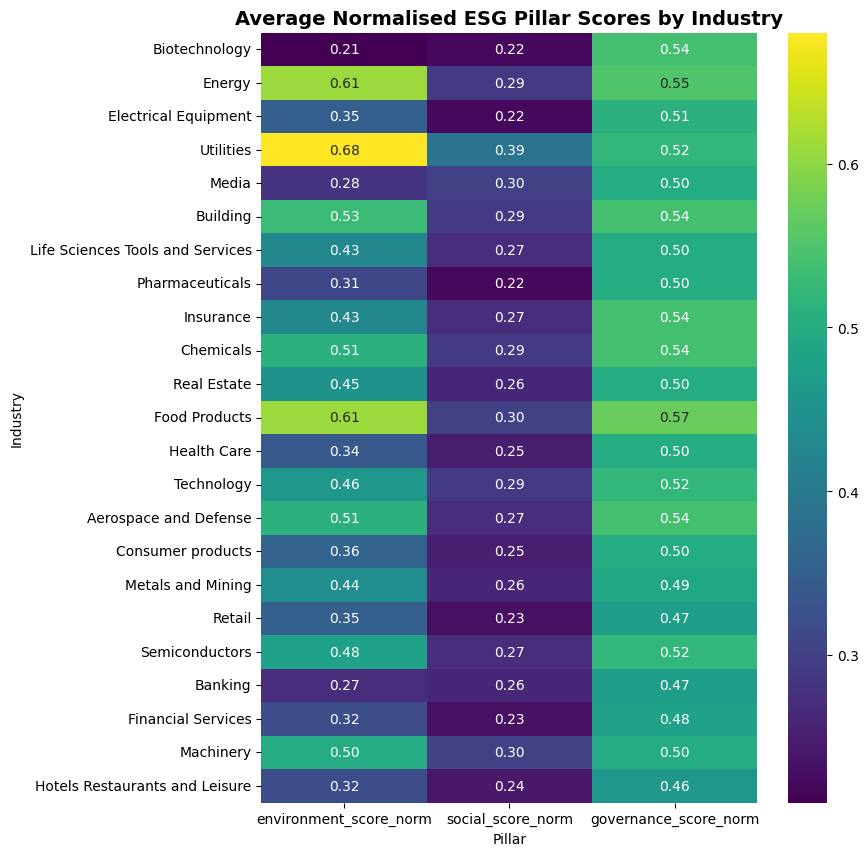

In [21]:
heatmap_data = industry_imbalance[["environment_score_norm", "social_score_norm", "governance_score_norm"]]

plt.figure(figsize=(8, 10))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", fmt=".2f")
plt.title("Average Normalised ESG Pillar Scores by Industry", fontsize=14, fontweight="bold")
plt.xlabel("Pillar")
plt.ylabel("Industry")
plt.show()

### Visualising the pattern: heatmap

I think this heatmap showing average normalised pillar scores by industry (sorted by imbalance) is a real success. It tells the story of imbalance across ESG pillars really clearly. It shows a consistently low Social band across nearly all industries, a narrow mid-to-high Governance band, and high volatility in Environment. This reinforces both the finding that social lags almost everywhere as well as the two distinct imbalance shapes identified above.

An initial version used a red-to-green colour scale, but this was replaced with viridis in line with accessibility guidance against relying solely on red/green colour coding, which can be difficult to distinguish for viewers with colour vision deficiency. 

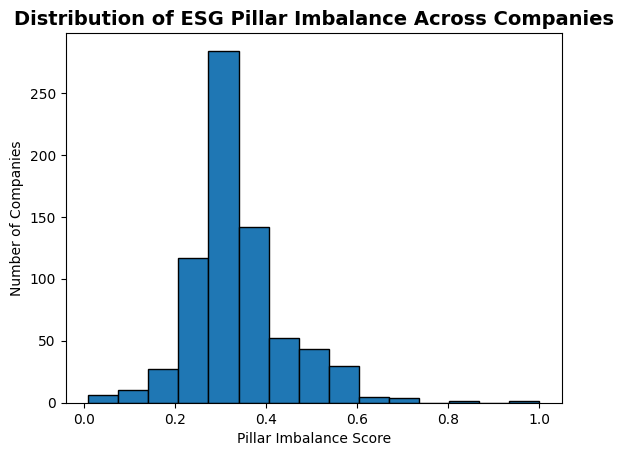

In [22]:
plt.hist(df["pillar_imbalance"], bins=15, edgecolor="black")
plt.title("Distribution of ESG Pillar Imbalance Across Companies", fontsize=14, fontweight="bold")
plt.xlabel("Pillar Imbalance Score")
plt.ylabel("Number of Companies")
plt.show()

In [29]:
balanced_count = (df["pillar_imbalance"] < 0.1).sum()
total_companies = df.shape[0]
balanced_pct = round((balanced_count / total_companies) * 100, 1)

print(f"Only {balanced_count} of {total_companies} companies ({balanced_pct}%) scored below 0.1 on the pillar imbalance metric,\nshowing that highly balanced ESG performance is rare across this dataset.")

Only 7 of 722 companies (1.0%) scored below 0.1 on the pillar imbalance metric,
showing that highly balanced ESG performance is rare across this dataset.


In [31]:
middle_band_count = ((df["pillar_imbalance"] >= 0.2) & (df["pillar_imbalance"] <= 0.4)).sum()
middle_band_pct = round((middle_band_count / total_companies) * 100, 1)

print(f"{middle_band_count} of {total_companies} companies ({middle_band_pct}%) fall within the 0.2–0.4 imbalance range,\nshowing the typical level of pillar imbalance across this dataset.")

546 of 722 companies (75.6%) fall within the 0.2–0.4 imbalance range,
showing the typical level of pillar imbalance across this dataset.


## Distribution of pillar imbalance across individual companies

The industry-level analysis showed which industries tend toward higher or lower average imbalance. But this doesn't show how imbalance is distributed among individual companies across the whole dataset. I created a histogram of pillar_imbalance across all 722 companies, using 15 bins to group the continuous imbalance scores into readable ranges.

The resulting distribution is right-skewed. Most companies cluster in a relatively narrow band, with imbalance scores tapering off gradually into a long thin tail toward the maximum possible value of 1.0. This shape makes sense given the metric's design because balanced performance requires all three pillar scores to be similarly close to each other, while severe imbalance (like CMS Energy's score of 1.0) requires a company to sit at both an extreme high and an extreme low simultaneously. This condition is comparatively rare.

To quantify this rather than rely on visual impression alone, two specific thresholds were calculated directly from the data:

1. 7 of 722 companies (1.0%) scored below 0.1 on the pillar imbalance metric. 
2. 546 of 722 companies (75.6%) fall within the 0.2–0.4 imbalance range.

This adds an important insight to the industry-level findings. While certain industries (e.g. Biotechnology, Utilities) show higher average imbalance, this histogram confirms that some degree of pillar imbalance is the norm across the dataset generally, rather than being concentrated in a small handful of extreme cases. Severe imbalance, of the kind seen in CMS Energy, is the exception rather than the rule and most companies sit in a moderate middle ground rather than at either extreme of perfect balance or severe lopsidedness.

## Using generative AI to produce a narrative summary
Throughout this project I have used Claude in a a variety of ways:

1. Project manager - I gave Claude the assessment criteria and my proposed approach so that it could create a project plan with clear stages and timelines.
2. troubleshooter/debugger - I used Claude to find solutions to problems or help me correct issues in code. This was most valuable in the rebuilding df_filtered example provided above but it also helped me with diagnosing a persistent ModuleNotFoundError: pkg_resources error during environment setup and resolving file path errors.
3. Data analyst - I ran my observations and plots through Claude to explore them further and make sure I was using the right language. I also used it to challenge my approach - for example, it highlighted accessibility concerns around the use of red-green heatmap colour scale in the heatmap.
 
 To demonstrate AI-assisted storytelling (LO3.2), I used Claude to synthesise the key findings from this analysis into a single narrative summary, without providing it any additional analysis beyond what's already in this notebook.

### The AI-generated narrative:

Across 722 mid- and large-cap companies, this analysis set out to answer a simple question: do companies genuinely balance their Environmental, Social, and Governance performance, or does strong performance in one area often mask weakness in another? The data suggests the latter is far more common than the former.

The clearest pattern in the dataset is Social performance. Once scores were placed on a common scale, Social emerged as the weakest of the three pillars in 21 of 23 industries examined — not a scattered issue affecting a handful of companies, but a near-universal trend. Governance, by contrast, tends to be comparatively strong, though a closer look reveals it never reaches the very top rating tier anywhere in the dataset — every company's governance ceiling sits just below "excellent," regardless of industry.

Digging into which industries show the most pronounced imbalance revealed two distinct patterns. Utilities and Energy companies lean heavily on strong Environmental performance, plausibly reflecting the direct environmental exposure and regulatory scrutiny these sectors face. Biotechnology and Electrical Equipment tell a different story: here, Governance carries the average while both Environment and Social lag behind together — a "propped up" profile rather than a single standout strength.

No single company illustrates this better than CMS Energy, an established utility company that scored among the highest in the entire dataset on Social performance, while scoring the lowest on Governance — a live example of exactly the imbalance pattern this analysis set out to investigate, hiding in plain sight within a single company's rating.

At the individual company level, though, extreme imbalance like CMS Energy's is the exception rather than the rule. Most companies cluster in a moderate imbalance range, with severe lopsidedness confined to a smaller tail of cases. The overall picture, then, is not one of universal dysfunction, but of a consistent structural weak spot — Social performance — sitting beneath otherwise reasonably balanced ESG profiles for most companies, punctuated by a handful of industries and individual companies where the imbalance is much more pronounced.

### My reflection

I think this AI summary captures the essence of what this project found. But there are some issues. The main one is the use of the word "mask" in the first paragraph. This makes it seem like companies are intentionally trying to hide thier performance in lower scoring pillars. This is not an accurate representation of why these imbalances might exist. These are huge companies working across a variety of industries. The complexity of trying to roll out policies and accurately measure thier results across large teams and geographically diverse operations is no joke. Also, different industries will be subject to varying levels of regulatory scrutiny when it comes to environmental performance. Saying that companies are actively trying to mask areas of thier performance is essentially accusing them of attempting to commit fraud.

## Limitations of the dataset and my approach 

Even though I am happy with the end result, there are a number of issues that limit my ability to gain deeper insights.

### Opaque rating methodology

This dataset does not disclose which third-party agency (or agencies) produced the ESG ratings, nor their scoring methodology. This limitation surfaced repeatedly during my analysis. It prevented a confident explanation for why Governance never reaches the top rating tier anywhere in the dataset and meant the CMS Energy governance outlier couldn't be independently verified against an external source. Without visibility into the underlying methodology, confidence in cross-pillar and cross-company comparisons relies on trust in an unnamed rating provider.

### Temporal spread of processing dates

 While the majority of companies (~75%) were processed within a roughly two-month window, a smaller subset were rated months later. Since this project treats the dataset as a single cross-sectional snapshot, this introduces a minor comparability concern. It is possible, although unlikely, that a company's underlying ESG conditions could have changed between the earliest and latest rated entries.

### Small-industry exclusion

Industry-level comparisons excluded any industry with fewer than 10 companies, as well as the "Unknown" category. This reduced the analysis from 44 to 23 industries. This threshold was chosen at a natural gap in the company-count distribution and improves the statistical reliability of industry averages. But it also means that the analysis says nothing about how imbalance manifests in smaller, excluded industries (e.g. Tobacco, with only 2 companies).

### Unmerged related industry categories

During data cleaning, several industry labels were identified as closely related but conceptually distinct (e.g. "Banking" as a subset of "Financial Services," "Automobiles" vs. "Auto Components"). These were deliberately left unmerged, since consolidating them would impose a subjective industry taxonomy not present in the original dataset. An alternative approach like consulting a standard industry classification system such as GICS to regroup categories, could enable higher-level sector analysis. But was outside the scope of this project.

### Limitations of a single imbalance metric

The pillar_imbalance metric (max minus min of normalised pillar scores) proved effective for ranking companies and industries by overall imbalance, but analysis revealed it cannot distinguish between different underlying causes of imbalance. Utilities and Energy show high imbalance driven by one exceptionally strong pillar (Environment), while Biotechnology and Electrical Equipment show high imbalance driven by two consistently weak pillars propped up by a stronger third (Governance). Both register identically on the imbalance score despite representing meaningfully different situations. A more complete alternative approach might involve a categorical classification of imbalance "type" alongside the numeric score, rather than relying on a single summary number.